In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"lukealley","key":"8084d6e800acf53ed29302ae27d43b41"}'}

In [2]:
import os, shutil

os.makedirs("/root/.kaggle", exist_ok=True)
shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 600)

print("Kaggle ready")

Kaggle ready


In [3]:
!kaggle datasets download -d meowmeowmeowmeowmeow/gtsrb-german-traffic-sign
!unzip -q gtsrb-german-traffic-sign.zip

print("Dataset downloaded")

Dataset URL: https://www.kaggle.com/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign
License(s): CC0-1.0
100% 612M/612M [00:04<00:00, 157MB/s]

Dataset downloaded


In [4]:
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [5]:
dataset_path = "Train"

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train = datagen.flow_from_directory(
    dataset_path,
    target_size=(32,32),
    subset="training"
)

val = datagen.flow_from_directory(
    dataset_path,
    target_size=(32,32),
    subset="validation"
)

Found 31368 images belonging to 43 classes.
Found 7841 images belonging to 43 classes.


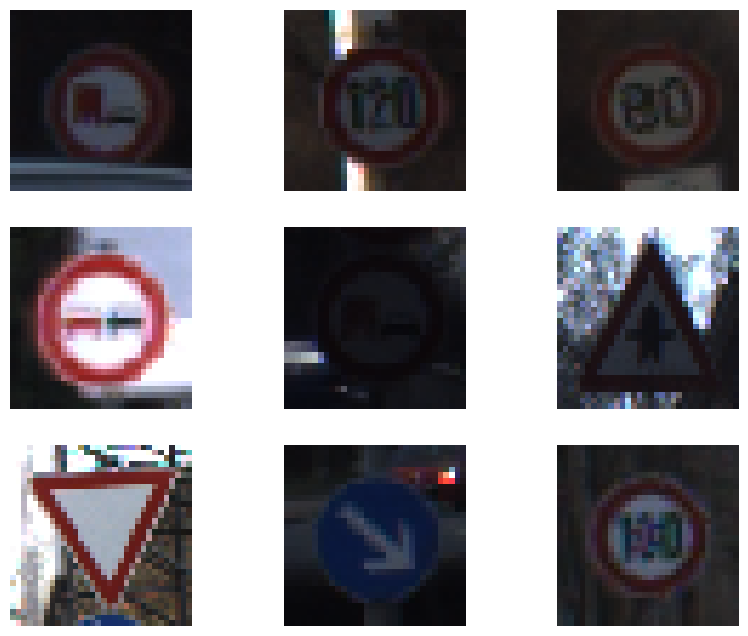

In [6]:
images, labels = next(train)

plt.figure(figsize=(10,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis("off")
plt.show()

In [7]:
model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)),
    MaxPooling2D(),
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(),
    Flatten(),
    Dense(64,activation='relu'),
    Dense(train.num_classes,activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
history = model.fit(train, validation_data=val, epochs=5)

Epoch 1/5
981/981 ━━━━━━━━━━━━━━━━━━━━ 65s 64ms/step - accuracy: 0.6968 - loss: 1.1261 - val_accuracy: 0.8264 - val_loss: 0.6093
Epoch 2/5
981/981 ━━━━━━━━━━━━━━━━━━━━ 63s 64ms/step - accuracy: 0.9528 - loss: 0.1746 - val_accuracy: 0.8785 - val_loss: 0.4704
Epoch 3/5
981/981 ━━━━━━━━━━━━━━━━━━━━ 61s 62ms/step - accuracy: 0.9760 - loss: 0.0932 - val_accuracy: 0.8856 - val_loss: 0.4918
Epoch 4/5
981/981 ━━━━━━━━━━━━━━━━━━━━ 61s 62ms/step - accuracy: 0.9837 - loss: 0.0616 - val_accuracy: 0.8981 - val_loss: 0.4854
Epoch 5/5
981/981 ━━━━━━━━━━━━━━━━━━━━ 62s 63ms/step - accuracy: 0.9886 - loss: 0.0422 - val_accuracy: 0.9060 - val_loss: 0.4210


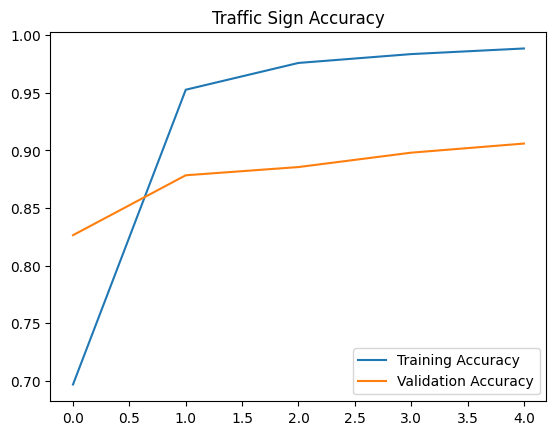

In [9]:
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Traffic Sign Accuracy")
plt.legend()
plt.show()

In [10]:
model.evaluate(val)

246/246 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.9060 - loss: 0.4210


[0.42103561758995056, 0.9060068726539612]